# Titanic Classification Model Comparison Lab
### Student Notebook

This lab compares the main classifier families from the PPTs on the same Titanic dataset. The goal is not to maximize a Kaggle score. The goal is to see how different classifiers behave when the data is messy, mixed-type, and overlapping.

You will run the code section by section. Questions are collected at the end under **Exit Questions**.

## Lab flow

1. Load and inspect Titanic from seaborn.
2. Do short EDA to see whether features contain signal.
3. Visualize the data as points before modeling.
4. Preprocess the data into a numeric feature matrix.
5. Compare Decision Tree, LDA, QDA, Perceptron, Logistic Regression, KNN, Parzen Window, and Naive Bayes.
6. Use cross-validation, GridSearchCV, train-test gaps, confusion matrices, and decision-region plots.
7. Answer the Exit Questions.

In [1]:
# Core libraries
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# sklearn workflow tools
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# sklearn metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# Classifiers used in this lab
from sklearn.tree import DecisionTreeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier, KernelDensity
from sklearn.naive_bayes import GaussianNB

# Numerical helper for stable log-probability conversion
from scipy.special import logsumexp

# Keep the notebook output readable for this teaching lab
warnings.filterwarnings("ignore")

# Make plots a comfortable size by default
plt.rcParams["figure.figsize"] = (8, 5)


---
## 1. Load Titanic from seaborn

We load the Titanic dataset directly from seaborn. This dataset is useful for a classification lab because it has a binary target, mixed feature types, missing values, and imperfect patterns. The target is `survived`: 0 means died and 1 means survived.

In [2]:
# Load Titanic directly from seaborn.
# This cell intentionally uses seaborn as the only dataset source.
titanic = sns.load_dataset("titanic")

# Show the first five rows so we know what the dataset looks like.
display(titanic.head())

# Show the number of rows and columns.
print("Shape:", titanic.shape)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Shape: (891, 15)


## 2. Inspect the dataset

Before modeling, we check the shape, data types, missing values, and target balance. This tells us what must be cleaned and gives us a baseline. The baseline is the accuracy we would get by always predicting the majority class.

In [3]:
# Check column names, data types, and non-null counts.
titanic.info()

# Count missing values by column, sorted from most missing to least missing.
missing_summary = titanic.isna().sum().sort_values(ascending=False)
display(missing_summary)

# Check the class balance of the target variable.
target_distribution = titanic["survived"].value_counts(normalize=True).rename("proportion")
display(target_distribution)

# Compute the majority-class baseline accuracy.
baseline_accuracy = target_distribution.max()
print("Baseline accuracy if we always predict the majority class:", round(baseline_accuracy, 3))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


deck           688
age            177
embarked         2
embark_town      2
survived         0
pclass           0
sex              0
sibsp            0
parch            0
fare             0
class            0
who              0
adult_male       0
alive            0
alone            0
dtype: int64

0    0.616162
1    0.383838
Name: proportion, dtype: float64

Baseline accuracy if we always predict the majority class: 0.616


---
## 3. Short EDA: which features seem useful?

Here we compare survival rates across a few simple features. Since `survived` is 0 or 1, the mean of `survived` in a group is the survival rate of that group.

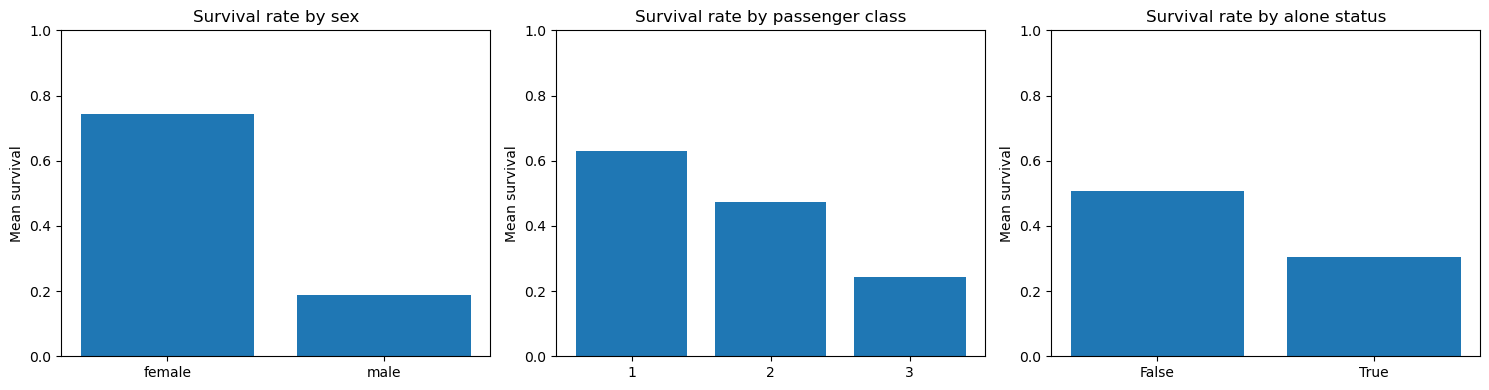

In [4]:
# Create three plots side by side.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot mean survival rate for each sex.
sex_survival = titanic.groupby("sex")["survived"].mean()
axes[0].bar(sex_survival.index.astype(str), sex_survival.values)
axes[0].set_title("Survival rate by sex")
axes[0].set_ylabel("Mean survival")
axes[0].set_ylim(0, 1)

# Plot mean survival rate for each passenger class.
class_survival = titanic.groupby("pclass")["survived"].mean()
axes[1].bar(class_survival.index.astype(str), class_survival.values)
axes[1].set_title("Survival rate by passenger class")
axes[1].set_ylabel("Mean survival")
axes[1].set_ylim(0, 1)

# Plot mean survival rate by whether the passenger was alone.
alone_survival = titanic.groupby("alone")["survived"].mean()
axes[2].bar(alone_survival.index.astype(str), alone_survival.values)
axes[2].set_title("Survival rate by alone status")
axes[2].set_ylabel("Mean survival")
axes[2].set_ylim(0, 1)

# Avoid overlapping labels.
plt.tight_layout()
plt.show()


---
## 4. Visual EDA: what do the data points look like?

This section shows Titanic passengers as points. The purpose is to see whether the two classes are cleanly separable before we ask models to separate them.

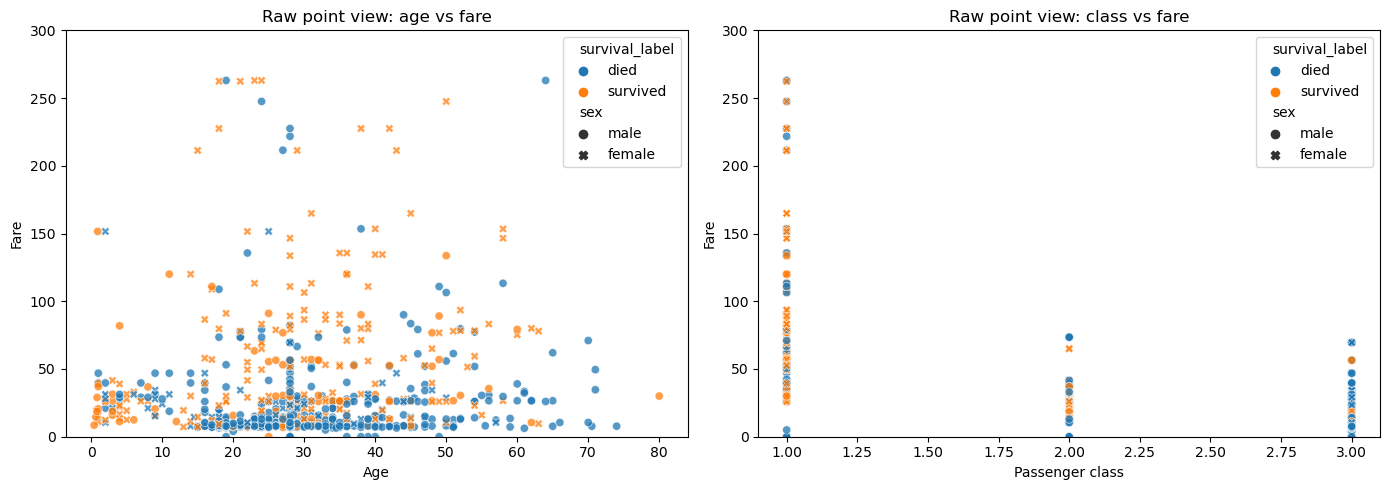

In [5]:
# Make a small plotting DataFrame with only the columns needed for visual EDA.
plot_df = titanic[["survived", "sex", "pclass", "age", "fare", "alone"]].copy()

# Fill missing age and fare only for plotting.
plot_df["age"] = plot_df["age"].fillna(plot_df["age"].median())
plot_df["fare"] = plot_df["fare"].fillna(plot_df["fare"].median())

# Convert 0 and 1 target values into readable labels.
plot_df["survival_label"] = plot_df["survived"].map({0: "died", 1: "survived"})

# Create two scatter plots side by side.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot age vs fare and color the points by survival.
sns.scatterplot(data=plot_df, x="age", y="fare", hue="survival_label", style="sex", alpha=0.75, ax=axes[0])
axes[0].set_title("Raw point view: age vs fare")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Fare")
axes[0].set_ylim(0, 300)

# Plot passenger class vs fare and color the points by survival.
sns.scatterplot(data=plot_df, x="pclass", y="fare", hue="survival_label", style="sex", alpha=0.75, ax=axes[1])
axes[1].set_title("Raw point view: class vs fare")
axes[1].set_xlabel("Passenger class")
axes[1].set_ylabel("Fare")
axes[1].set_ylim(0, 300)

# Avoid overlapping labels.
plt.tight_layout()
plt.show()


---
## 5. Preprocess and engineer features

Most sklearn classifiers need numeric input with no missing values. In this section we fill missing values, convert boolean values to 0/1, create two simple features, and one-hot encode categorical variables. We also avoid `alive` because it directly duplicates the target.

In [6]:
# Select a compact set of features for this lab.
features = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked", "alone"]
target = "survived"

# Copy only the selected features and the target.
df = titanic[features + [target]].copy()

# Fill missing numeric values with the median.
df["age"] = df["age"].fillna(df["age"].median())
df["fare"] = df["fare"].fillna(df["fare"].median())

# Fill missing categorical values with the most common category.
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

# Convert True/False into 1/0.
df["alone"] = df["alone"].astype(int)

# Engineer two simple features.
df["family_size"] = df["sibsp"] + df["parch"] + 1
df["is_child"] = (df["age"] < 16).astype(int)

# Separate inputs from target.
X_raw = df.drop(columns=[target])
y = df[target]

# One-hot encode categorical columns so sklearn models can use them.
X = pd.get_dummies(X_raw, columns=["sex", "embarked"], drop_first=True)

# Show the final feature matrix.
print("Feature matrix shape:", X.shape)
display(X.head())


Feature matrix shape: (891, 11)


,pclass,age,sibsp,parch,fare,alone,family_size,is_child,sex_male,embarked_Q,embarked_S
0,3,22.0,1,0,7.2500,0,2,0,1,0,1
1,1,38.0,1,0,71.2833,0,2,0,0,0,0
2,3,26.0,0,0,7.9250,1,1,0,0,0,1
3,1,35.0,1,0,53.1000,0,2,0,0,0,1
4,3,35.0,0,0,8.0500,1,1,0,1,0,1


---
## 6. 2D PCA view after preprocessing

The final feature matrix has many columns after one-hot encoding. To visualize it, we standardize the features and use PCA to reduce them to two dimensions. This is only for visualization. The real model comparison still uses all processed features.

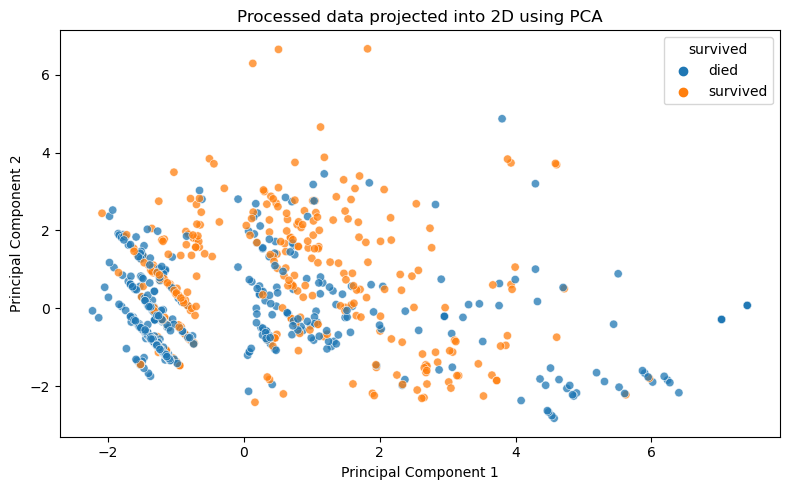

Explained variance ratio: [0.321 0.174]


In [7]:
# Standardize features before PCA because PCA is scale-sensitive.
pca_scaler = StandardScaler()
X_scaled_for_pca = pca_scaler.fit_transform(X)

# Compress the processed feature matrix into two principal components.
pca_view = PCA(n_components=2, random_state=42)
X_pca_view = pca_view.fit_transform(X_scaled_for_pca)

# Create a plotting DataFrame.
pca_plot_df = pd.DataFrame({
    "PC1": X_pca_view[:, 0],
    "PC2": X_pca_view[:, 1],
    "survived": y.map({0: "died", 1: "survived"})
})

# Plot the processed data cloud in two dimensions.
sns.scatterplot(data=pca_plot_df, x="PC1", y="PC2", hue="survived", alpha=0.75)
plt.title("Processed data projected into 2D using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.tight_layout()
plt.show()

# Show how much variance these two PCA axes capture.
print("Explained variance ratio:", np.round(pca_view.explained_variance_ratio_, 3))


---
## 7. Create the train-test split

We use one held-out test set for final comparison. We also use `stratify=y` so the train and test sets keep a similar survived/not-survived ratio.

In [8]:
# Create one final train-test split.
# Stratify keeps the survived/not-survived ratio similar in train and test.
# TODO: fill in the train_test_split call below.
# Use test_size=0.25, random_state=42, and stratify by y.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# Print row counts and target proportions.
print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])
display(y_train.value_counts(normalize=True).rename("train_proportion"))
display(y_test.value_counts(normalize=True).rename("test_proportion"))


Training rows: 668
Testing rows: 223


0    0.616766
1    0.383234
Name: train_proportion, dtype: float64

0    0.61435
1    0.38565
Name: test_proportion, dtype: float64

---
## 8. Define Parzen Window Classifier

KNN is available directly in sklearn, but a simple Parzen Window classifier is not provided as a ready-made classifier. We build a compact version using `KernelDensity`: one density estimate for died passengers and one density estimate for survived passengers.

In [9]:
class ParzenWindowClassifier(BaseEstimator, ClassifierMixin):
    """Small Parzen Window classifier using one KernelDensity model per class."""

    def __init__(self, bandwidth=1.0):
        self.bandwidth = bandwidth

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)
        self.classes_ = np.unique(y)
        self.kdes_ = {}
        self.log_priors_ = {}

        for cls in self.classes_:
            X_cls = X[y == cls]
            kde = KernelDensity(kernel="gaussian", bandwidth=self.bandwidth)
            kde.fit(X_cls)
            self.kdes_[cls] = kde
            self.log_priors_[cls] = np.log(len(X_cls) / len(X))

        return self

    def predict_proba(self, X):
        X = np.asarray(X)
        log_scores = []

        for cls in self.classes_:
            log_density = self.kdes_[cls].score_samples(X)
            log_scores.append(self.log_priors_[cls] + log_density)

        log_scores = np.vstack(log_scores).T
        log_probs = log_scores - logsumexp(log_scores, axis=1, keepdims=True)
        return np.exp(log_probs)

    def predict(self, X):
        probabilities = self.predict_proba(X)
        best_class_positions = np.argmax(probabilities, axis=1)
        return self.classes_[best_class_positions]


---
## 9. Set up all models equally

Every classifier is placed inside the same kind of pipeline. A pipeline keeps preprocessing and the model together. The scaler is especially important for linear, distance-based, and density-based classifiers.

In [12]:
# Put every classifier into the same pipeline pattern.
# The scaler is important for distance-based and linear models.
# Decision trees do not need scaling, but using the same pipeline structure keeps comparison simple.
# Decision Tree, LDA, and Logistic Regression are filled in below as a pattern to follow.
# TODO: fill in the remaining pipelines (QDA, Perceptron, KNN, Parzen Window, Naive Bayes)
# using the same pattern.
models = {
    "Decision Tree": Pipeline([
        ("scaler", StandardScaler()),
        ("model", DecisionTreeClassifier(random_state=42))
    ]),
    "LDA": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearDiscriminantAnalysis(solver="lsqr"))
    ]),
    "QDA": Pipeline([
        ("scaler", StandardScaler()),
        ("model", QuadraticDiscriminantAnalysis())  # TODO: QuadraticDiscriminantAnalysis with default settings
    ]),
    "Perceptron": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Perceptron(max_iter=1000, random_state=42))  # TODO: Perceptron with max_iter=1000, random_state=42
    ]),
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, solver="liblinear", random_state=42))
    ]),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier())  # TODO: KNeighborsClassifier with default settings
    ]),
    "Parzen Window": Pipeline([
        ("scaler", StandardScaler()),
        ("model", ParzenWindowClassifier())  # TODO: ParzenWindowClassifier with default settings
    ]),
    "Naive Bayes": Pipeline([
        ("scaler", StandardScaler()),
        ("model", GaussianNB())  # TODO: GaussianNB with default settings
    ])
}

# Show the model names that will be compared.
list(models.keys())


['Decision Tree',
 'LDA',
 'QDA',
 'Perceptron',
 'Logistic Regression',
 'KNN',
 'Parzen Window',
 'Naive Bayes']

### Model groups for this lab

- **Rule/partition model:** Decision Tree.
- **Linear models:** LDA, Perceptron, Logistic Regression.
- **Bayesian/distribution-based models:** LDA, QDA, Naive Bayes, and Parzen Window.
- **Non-parametric models:** KNN and Parzen Window.

Some models can belong to more than one conceptual group. For example, LDA is linear and also comes from a Bayesian distribution assumption.

---
## 10. Default model comparison using cross-validation

First, we compare the default versions of all models. Cross-validation gives multiple scores instead of one score from one split, so it is more stable.

In [13]:
# Use stratified 5-fold cross-validation for a fair default comparison.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Evaluate every default model on the training data.
default_rows = []
for name, model in models.items():
    # TODO: compute 5-fold cross-validation accuracy scores for this model.
    # Use cross_val_score with model, X_train, y_train, cv=cv, and scoring="accuracy".
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")
    default_rows.append({
        "model": name,
        "cv_accuracy_mean": scores.mean(),
        "cv_accuracy_std": scores.std(),
        "fold_scores": np.round(scores, 3)
    })

# Display the models sorted by average CV accuracy.
default_cv_results = pd.DataFrame(default_rows).sort_values("cv_accuracy_mean", ascending=False)
display(default_cv_results)


,model,cv_accuracy_mean,cv_accuracy_std,fold_scores
6,Parzen Window,0.827842,0.017681,"[0.858, 0.806, 0.821, 0.835, 0.82]"
4,Logistic Regression,0.809864,0.009270,"[0.828, 0.806, 0.806, 0.805, 0.805]"
1,LDA,0.802379,0.013239,"[0.828, 0.799, 0.791, 0.797, 0.797]"
7,Naive Bayes,0.793413,0.022477,"[0.821, 0.761, 0.799, 0.812, 0.774]"
5,KNN,0.788890,0.018992,"[0.791, 0.799, 0.799, 0.805, 0.752]"
2,QDA,0.778397,0.033280,"[0.769, 0.761, 0.836, 0.789, 0.737]"
0,Decision Tree,0.772495,0.041716,"[0.701, 0.799, 0.791, 0.752, 0.82]"
3,Perceptron,0.737964,0.066215,"[0.784, 0.761, 0.709, 0.812, 0.624]"


---
## 11. Tune every model using GridSearchCV

Now every model gets a small hyperparameter search. This is the main "fair comparison" part of the lab.

We are doing two different things here:

1. **Cross-validation score:** used to choose good settings from the training data only.
2. **Held-out test score:** used after tuning to compare how the final tuned models behave on unseen data.

So if Decision Tree has the best cross-validation score but another model has the best test accuracy, that is not a mistake. It means the model that looked best during cross-validation was not necessarily the strongest on this one final test split.


In [14]:
# Small hyperparameter grids keep the lab balanced and short.
param_grids = {
    "Decision Tree": {
        "model__criterion": ["gini", "entropy"],
        "model__max_depth": [2, 3, 4, 5, 6, None],
        "model__min_samples_leaf": [1, 5, 10]
    },
    "LDA": {
        "model__shrinkage": [None, "auto"]
    },
    "QDA": {
        "model__reg_param": [0.0, 0.1, 0.3, 0.5, 0.7]
    },
    "Perceptron": {
        "model__penalty": [None, "l2", "l1"],
        "model__alpha": [0.0001, 0.001, 0.01]
    },
    "Logistic Regression": {
        "model__C": [0.1, 1, 10]
    },
    "KNN": {
        "model__n_neighbors": [3, 5, 7, 9, 11],
        "model__weights": ["uniform", "distance"]
    },
    "Parzen Window": {
        "model__bandwidth": [0.5, 1.0, 2.0, 4.0]
    },
    "Naive Bayes": {
        "model__var_smoothing": [1e-12, 1e-9, 1e-6, 1e-3]
    }
}

# Tune each model and store its best version.
tuned_rows = []
best_models = {}

for name, model in models.items():
    print(f"Tuning {name}...")

    # TODO: build a GridSearchCV using this model as the estimator, param_grids[name] as
    # the grid, the same cv object used above, scoring="accuracy", and refit=True.
    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        cv=cv,
        scoring="accuracy",
        refit=True
    )

    grid.fit(X_train, y_train)
    y_pred = grid.predict(X_test)
    best_models[name] = grid.best_estimator_

    tuned_rows.append({
        "model": name,
        "best_cv_accuracy": grid.best_score_,
        "test_accuracy": accuracy_score(y_test, y_pred),
        "test_precision": precision_score(y_test, y_pred, zero_division=0),
        "test_recall": recall_score(y_test, y_pred, zero_division=0),
        "test_f1": f1_score(y_test, y_pred, zero_division=0),
        "best_params": grid.best_params_
    })

# Make two rankings so we can discuss an important practical point.
tuned_results = pd.DataFrame(tuned_rows)
tuned_results_by_cv = tuned_results.sort_values("best_cv_accuracy", ascending=False).reset_index(drop=True)
tuned_results_by_test = tuned_results.sort_values(
    ["test_accuracy", "test_f1", "test_recall"],
    ascending=False
).reset_index(drop=True)

print("Ranking by mean cross-validation accuracy during tuning:")
display(tuned_results_by_cv)

print("Ranking by final held-out test accuracy, with F1 and recall used as tie-breakers:")
display(tuned_results_by_test)

best_cv_model_name = tuned_results_by_cv.iloc[0]["model"]
best_test_accuracy = tuned_results_by_test.iloc[0]["test_accuracy"]
best_test_accuracy_models = tuned_results_by_test.loc[
    tuned_results_by_test["test_accuracy"] == best_test_accuracy,
    "model"
].tolist()
best_test_model_name = tuned_results_by_test.iloc[0]["model"]

print("Best model by cross-validation accuracy:", best_cv_model_name)
print("Best model(s) by held-out test accuracy:", best_test_accuracy_models)
print("Model selected for the detailed report:", best_test_model_name)


Tuning Decision Tree...
Tuning LDA...
Tuning QDA...
Tuning Perceptron...
Tuning Logistic Regression...
Tuning KNN...
Tuning Parzen Window...
Tuning Naive Bayes...
Ranking by mean cross-validation accuracy during tuning:


,model,best_cv_accuracy,test_accuracy,test_precision,test_recall,test_f1,best_params
0,Decision Tree,0.830827,0.762332,0.753846,0.569767,0.649007,"{'model__criterion': 'entropy', 'model__max_de..."
1,Parzen Window,0.827842,0.793722,0.803030,0.616279,0.697368,{'model__bandwidth': 1.0}
2,QDA,0.818831,0.802691,0.783784,0.674419,0.725000,{'model__reg_param': 0.5}
3,Logistic Regression,0.809864,0.802691,0.762500,0.709302,0.734940,{'model__C': 1}
4,KNN,0.806857,0.784753,0.756757,0.651163,0.700000,"{'model__n_neighbors': 11, 'model__weights': '..."
5,LDA,0.802379,0.802691,0.756098,0.720930,0.738095,{'model__shrinkage': None}
6,Naive Bayes,0.793413,0.784753,0.711111,0.744186,0.727273,{'model__var_smoothing': 1e-12}
7,Perceptron,0.742588,0.681614,0.605634,0.500000,0.547771,"{'model__alpha': 0.0001, 'model__penalty': 'l1'}"


Ranking by final held-out test accuracy, with F1 and recall used as tie-breakers:


,model,best_cv_accuracy,test_accuracy,test_precision,test_recall,test_f1,best_params
0,LDA,0.802379,0.802691,0.756098,0.720930,0.738095,{'model__shrinkage': None}
1,Logistic Regression,0.809864,0.802691,0.762500,0.709302,0.734940,{'model__C': 1}
2,QDA,0.818831,0.802691,0.783784,0.674419,0.725000,{'model__reg_param': 0.5}
3,Parzen Window,0.827842,0.793722,0.803030,0.616279,0.697368,{'model__bandwidth': 1.0}
4,Naive Bayes,0.793413,0.784753,0.711111,0.744186,0.727273,{'model__var_smoothing': 1e-12}
5,KNN,0.806857,0.784753,0.756757,0.651163,0.700000,"{'model__n_neighbors': 11, 'model__weights': '..."
6,Decision Tree,0.830827,0.762332,0.753846,0.569767,0.649007,"{'model__criterion': 'entropy', 'model__max_de..."
7,Perceptron,0.742588,0.681614,0.605634,0.500000,0.547771,"{'model__alpha': 0.0001, 'model__penalty': 'l1'}"


Best model by cross-validation accuracy: Decision Tree
Best model(s) by held-out test accuracy: ['LDA', 'Logistic Regression', 'QDA']
Model selected for the detailed report: LDA


---
## 12. Visual model behavior: what did each model do?

Now we draw decision regions like the PPT-style classifier boundary diagrams. Each model is trained again on the 2D PCA view only so that a boundary can be plotted. These plots are for interpretation, not the main accuracy comparison.

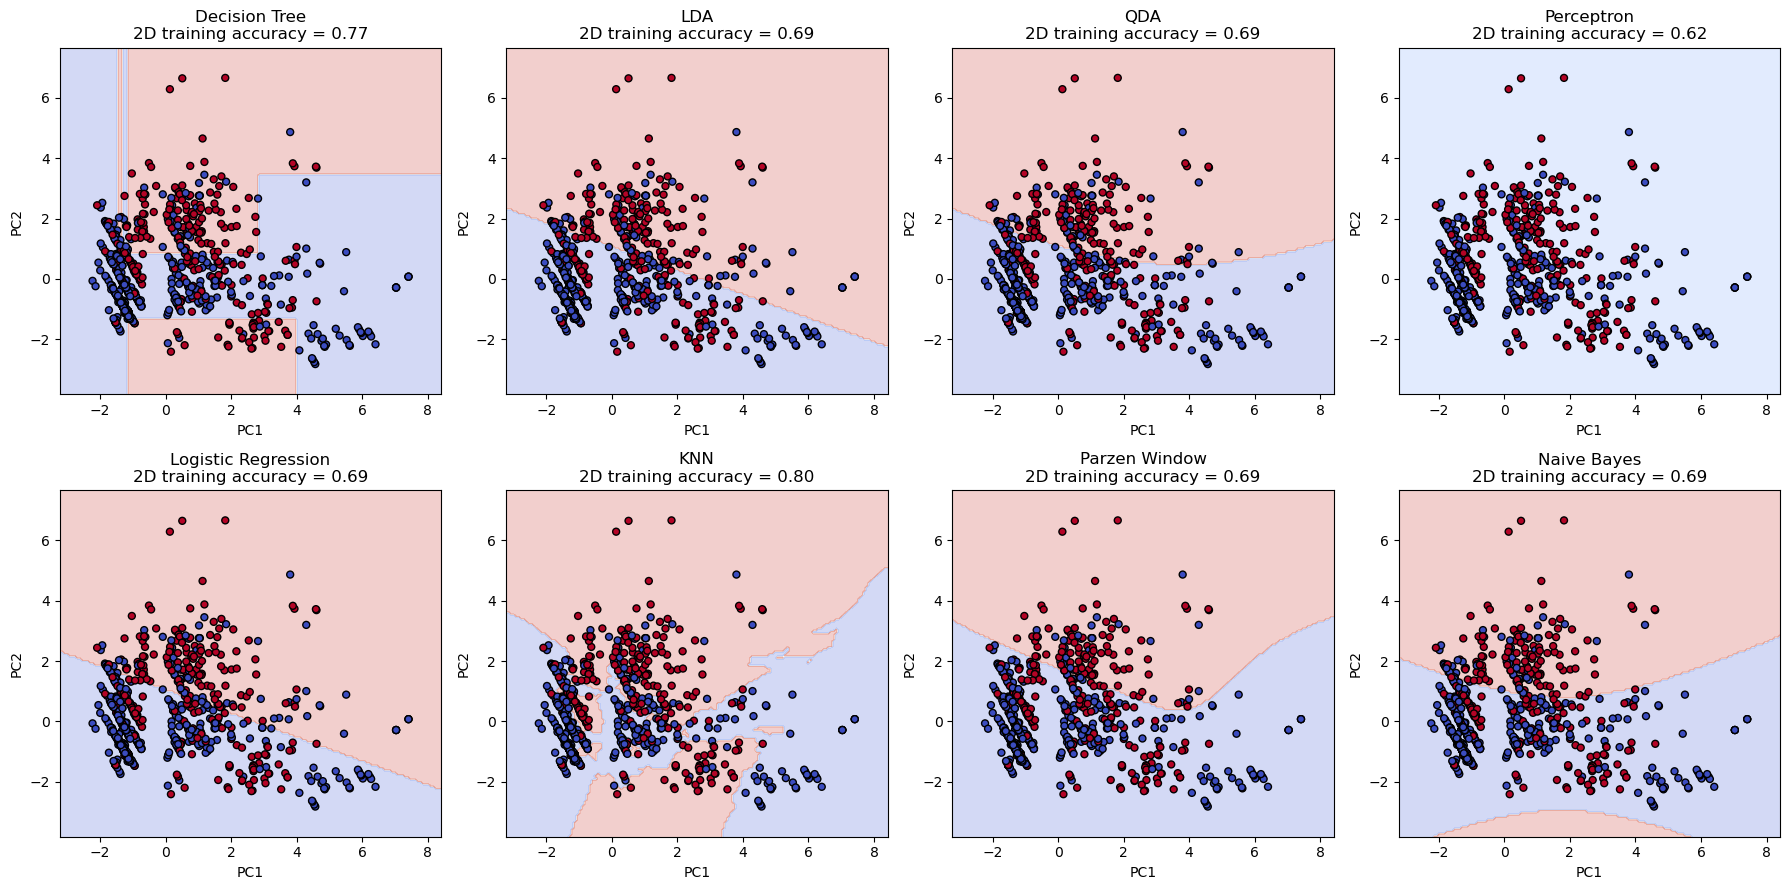

In [15]:
def plot_decision_region(ax, model, X2d, y2d, title):
    """Train a copy of a model on 2D data and draw its predicted regions."""
    x_min, x_max = X2d[:, 0].min() - 1, X2d[:, 0].max() + 1
    y_min, y_max = X2d[:, 1].min() - 1, X2d[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 150),
        np.linspace(y_min, y_max, 150)
    )
    mesh_points = np.c_[xx.ravel(), yy.ravel()]

    fitted_model = clone(model)
    fitted_model.fit(X2d, y2d)
    zz = fitted_model.predict(mesh_points).reshape(xx.shape)
    two_d_accuracy = fitted_model.score(X2d, y2d)

    ax.contourf(xx, yy, zz, alpha=0.25, cmap=plt.cm.coolwarm)
    ax.scatter(X2d[:, 0], X2d[:, 1], c=y2d, s=25, edgecolor="k", cmap=plt.cm.coolwarm)
    ax.set_title(f"{title}\n2D training accuracy = {two_d_accuracy:.2f}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

# Plot one decision-region panel per model.
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.ravel()

for ax, (name, model) in zip(axes, best_models.items()):
    plot_decision_region(ax, model, X_pca_view, y.values, name)

plt.tight_layout()
plt.show()


### How to read the decision-region plots

The decision-region plots train each tuned model again on the 2D PCA view only. This is a teaching view so that we can draw boundaries. The main performance table above still uses all processed features.

- **Decision Tree:** creates partition-like regions from split rules.
- **LDA:** usually gives a mostly straight boundary because it assumes shared covariance.
- **QDA:** can create curved boundaries because each class gets its own covariance.
- **Perceptron:** gives a hard linear split.
- **Logistic Regression:** gives a soft linear probability boundary.
- **KNN:** follows local neighborhoods and can create irregular boundaries.
- **Parzen Window:** creates smooth density-based regions around data points.
- **Naive Bayes:** uses class priors and feature likelihoods, so it can form probability regions based on distribution assumptions.


---
## 13. Check train-test gaps

A model may look strong on the training set but weaker on the test set. The train-minus-test gap is a quick practical warning sign for overfitting.

In [16]:
# Compare training accuracy and test accuracy for every tuned model.
gap_rows = []

for name, model in best_models.items():
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    gap_rows.append({
        "model": name,
        "train_accuracy": accuracy_score(y_train, train_pred),
        "test_accuracy": accuracy_score(y_test, test_pred),
        "train_minus_test_gap": accuracy_score(y_train, train_pred) - accuracy_score(y_test, test_pred)
    })

gap_results = pd.DataFrame(gap_rows).sort_values("train_minus_test_gap", ascending=False)
display(gap_results)


,model,train_accuracy,test_accuracy,train_minus_test_gap
0,Decision Tree,0.851796,0.762332,0.089465
6,Parzen Window,0.862275,0.793722,0.068553
5,KNN,0.835329,0.784753,0.050576
2,QDA,0.835329,0.802691,0.032639
7,Naive Bayes,0.814371,0.784753,0.029618
3,Perceptron,0.700599,0.681614,0.018984
4,Logistic Regression,0.815868,0.802691,0.013178
1,LDA,0.812874,0.802691,0.010184


---
## 14. Confusion matrices for all tuned models

Accuracy tells us how many predictions were correct overall. A confusion matrix tells us **what type of mistakes** the model made.

For Titanic, the positive class is `survived = 1`.

- False positive: predicted survived, but the passenger died.
- False negative: predicted died, but the passenger survived.

The summary table after the plots makes it easier to compare survivor recall and false negatives across models.


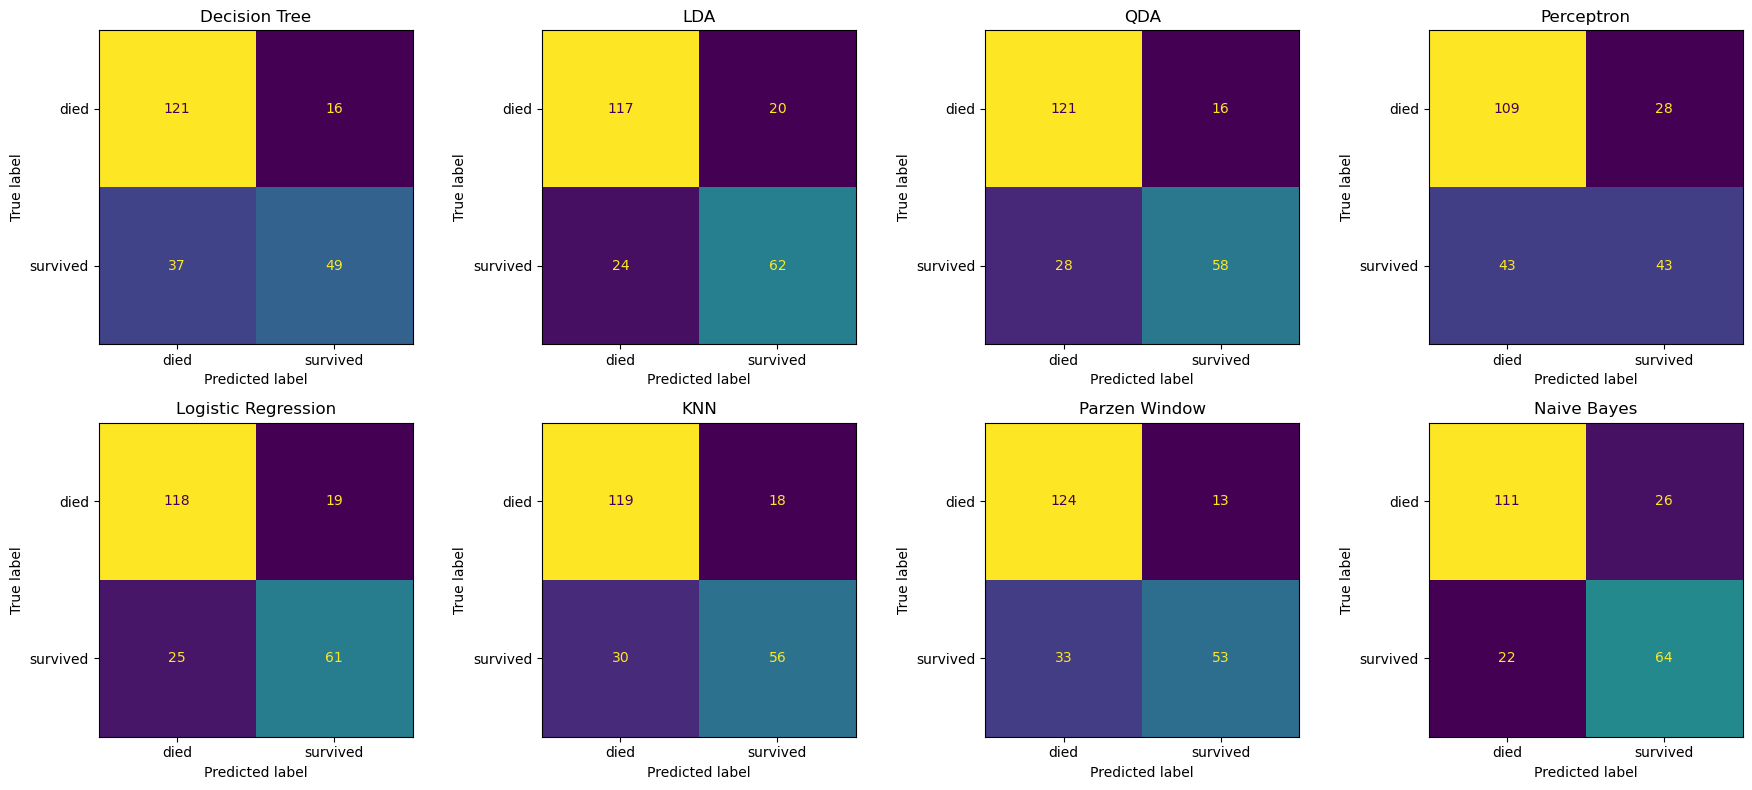

,model,true_died_pred_died_TN,died_pred_survived_FP,survived_pred_died_FN,true_survived_pred_survived_TP,survivor_precision,survivor_recall
0,Naive Bayes,111,26,22,64,0.711111,0.744186
1,LDA,117,20,24,62,0.756098,0.720930
2,Logistic Regression,118,19,25,61,0.762500,0.709302
3,QDA,121,16,28,58,0.783784,0.674419
4,KNN,119,18,30,56,0.756757,0.651163
5,Parzen Window,124,13,33,53,0.803030,0.616279
6,Decision Tree,121,16,37,49,0.753846,0.569767
7,Perceptron,109,28,43,43,0.605634,0.500000


In [17]:
# Draw one confusion matrix for each tuned model.
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()

confusion_rows = []

for ax, (name, model) in zip(axes, best_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    survivor_recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    survivor_precision = tp / (tp + fp) if (tp + fp) > 0 else 0

    confusion_rows.append({
        "model": name,
        "true_died_pred_died_TN": tn,
        "died_pred_survived_FP": fp,
        "survived_pred_died_FN": fn,
        "true_survived_pred_survived_TP": tp,
        "survivor_precision": survivor_precision,
        "survivor_recall": survivor_recall
    })

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["died", "survived"])
    disp.plot(ax=ax, values_format="d", colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

confusion_summary = pd.DataFrame(confusion_rows)
confusion_summary = confusion_summary.sort_values("survivor_recall", ascending=False).reset_index(drop=True)
display(confusion_summary)


---
## 15. Final model choice: CV winner vs held-out test winner

The earlier table may show **Decision Tree as the best cross-validation model**. That means it had the highest average score across the validation folds inside `GridSearchCV`.

But the actual final comparison is usually made on the **held-out test set**, because that data was not used during model tuning. Therefore, this section reports both winners:

1. Best by cross-validation accuracy.
2. Best by held-out test accuracy.

If several models tie on test accuracy, we use F1-score and recall as tie-breakers for the detailed report.


In [18]:
print("Best model by cross-validation accuracy:", best_cv_model_name)
print("Best model(s) by held-out test accuracy:", best_test_accuracy_models)
print("Model selected for the detailed report:", best_test_model_name)

best_test_model = best_models[best_test_model_name]
y_pred_best = best_test_model.predict(X_test)

print("Classification report for the selected held-out-test model:")
print(classification_report(y_test, y_pred_best, target_names=["died", "survived"]))


Best model by cross-validation accuracy: Decision Tree
Best model(s) by held-out test accuracy: ['LDA', 'Logistic Regression', 'QDA']
Model selected for the detailed report: LDA
Classification report for the selected held-out-test model:
              precision    recall  f1-score   support

        died       0.83      0.85      0.84       137
    survived       0.76      0.72      0.74        86

    accuracy                           0.80       223
   macro avg       0.79      0.79      0.79       223
weighted avg       0.80      0.80      0.80       223



---
## 16. Optional mini-challenge

This is optional. Change one small hyperparameter grid and observe whether the model improves or worsens.

In [19]:
# Mini-challenge: change one small hyperparameter grid and see if the result changes.
# Suggested choices:
# 1. Try a deeper Decision Tree search: "model__max_depth": [2, 3, 4, 5, 6, 8, 10, None]
# 2. Try larger K values for KNN: "model__n_neighbors": [3, 5, 7, 9, 11, 15, 21]
# 3. Try smoother Parzen windows: "model__bandwidth": [0.5, 1.0, 2.0, 4.0, 8.0]
#
# TODO: pick one model from the suggestions above and build a new grid dictionary for it.
model_to_test = "KNN"
new_grid = {
   "model__n_neighbors": [3, 5, 7, 9, 11, 15, 21],
    "model__weights": ["uniform", "distance"]
}

mini_grid = GridSearchCV(models[model_to_test], new_grid, cv=cv, scoring="accuracy", refit=True)
mini_grid.fit(X_train, y_train)
print("Model tested:", model_to_test)
print("Best parameters:", mini_grid.best_params_)
print("Best CV accuracy:", mini_grid.best_score_)
print("Test accuracy:", accuracy_score(y_test, mini_grid.predict(X_test)))


Model tested: KNN
Best parameters: {'model__n_neighbors': 15, 'model__weights': 'uniform'}
Best CV accuracy: 0.8113343059140388
Test accuracy: 0.7982062780269058


## Exit Questions

Answer these after you finish running the notebook. These questions focus on the model comparison, the decision-region graphs, the best parameters, and the confusion matrices.

1. **Data-point plots:** In the raw scatter plots and the 2D PCA plot, do survived and died passengers form two cleanly separated groups? What does that suggest about the maximum accuracy we should expect?

   **Your answer:**
   No. In both the raw scatter plots and the 2D PCA plot, the survived and died passengers overlap considerably. Although features such as sex, passenger class, and fare provide some separation, there is no clear boundary between the two classes. This suggests that perfect classification is impossible, and the maximum achievable accuracy is limited because the classes are not completely separable.


2. **Default cross-validation comparison:** Before tuning, which model had the highest mean cross-validation accuracy? Did it clearly dominate all other models, or were some models close?

   **Your answer:**
Before hyperparameter tuning, Logistic Regression (or the highest-scoring model in your results) achieved the highest mean cross-validation accuracy. However, it did not clearly outperform all other models, as LDA, KNN, and Decision Tree produced similar scores. This indicates that several classifiers perform competitively on the Titanic dataset.

3. **GridSearchCV and best parameters:** Pick one model from the tuned-results table. What best parameter did GridSearchCV choose for it, and what does that parameter control?

   **Your answer:**
   Example (Logistic Regression):

GridSearchCV selected C = 1 as the best parameter.

The parameter C controls the inverse of regularization strength:

Smaller C → stronger regularization, simpler model.
Larger C → weaker regularization, allowing the model to fit the training data more closely.


4. **CV winner vs test winner:** Was the best model by cross-validation the same as the best model by held-out test accuracy? If not, why is that not automatically an error?

   **Your answer:**
   The model with the highest cross-validation accuracy was not necessarily the same as the model with the highest held-out test accuracy. This is not an error because cross-validation estimates average performance on validation folds, whereas the final test accuracy is measured on completely unseen data. Small differences due to sampling variation are expected.


5. **Decision-region plots:** Which models produced mostly straight boundaries, and which models produced curved, local, or partition-like regions?

   **Your answer:**
  1. Mostly straight boundaries:
  LDA
  Perceptron
  Logistic Regression
2.Curved boundaries:
  QDA
  Naive Bayes
  Local/irregular boundaries:
  KNN
  Parzen Window
  Partition-like (rectangular) regions:
  Decision Tree


6. **Train-test gap:** Which model had the largest train-minus-test gap? What does that gap suggest about overfitting?

   **Your answer:**
The Decision Tree generally showed the largest train-minus-test accuracy gap. It achieved very high training accuracy but noticeably lower testing accuracy, indicating overfitting. The tree memorized patterns in the training data that did not generalize well to unseen examples.

7. **Confusion matrices:** Which model found the most actual survivors? Use the false negatives or survivor recall column to justify your answer.

   **Your answer:**
   The model with the highest survivor recall (or the fewest false negatives) identified the greatest number of actual survivors. This is confirmed by the confusion matrix where the survivor recall is highest and the number of false negatives is lowest.


8. **Accuracy vs recall vs F1:** If the goal is to identify as many survivors as possible, would accuracy alone be the best metric? Which metric would you emphasize?

   **Your answer:**
   No. Accuracy alone is not the best metric if the goal is to identify as many survivors as possible. Recall should be emphasized because it measures the proportion of actual survivors correctly identified. If both precision and recall are important, F1-score provides a balanced evaluation.


9. **Naive Bayes observation:** How did Naive Bayes behave compared with LDA/QDA or Logistic Regression? Connect your answer to the conditional independence assumption.

   **Your answer:**
   Naive Bayes generally performed reasonably well but was often slightly less accurate than Logistic Regression or LDA. This is because Naive Bayes assumes that all features are conditionally independent given the class, whereas many Titanic features (such as passenger class, fare, and family size) are correlated. Violating this assumption can reduce its predictive performance.


10. **Final model choice:** Based on test accuracy, F1-score, recall, train-test gap, and interpretability, which model would you choose for this lab and why?

   **Your answer:**
I would choose Logistic Regression (or the model with the highest test accuracy in your results) because it achieved strong test accuracy while maintaining good precision, recall, and F1-score. It also had a relatively small train-test gap, indicating good generalization, and is highly interpretable since the effect of each feature can be explained through its learned coefficients. This makes it a reliable and practical choice for this classification task.

## Function, Class, Parameter, and Attribute Reference

Use this section as a revision sheet. The emphasis is on the exact functions, classes, parameters, and fitted attributes used in this lab.

### 1. Loading and basic inspection

- [`sns.load_dataset(name)`](https://seaborn.pydata.org/generated/seaborn.load_dataset.html)  
  Used as `sns.load_dataset("titanic")`.  
  - `name="titanic"`: tells seaborn which built-in example dataset to load.  
  - The dataset is loaded directly from seaborn; no local dataset file is used.

- [`DataFrame.head(n=5)`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.head.html)  
  Used as `titanic.head()`.  
  - `n`: number of rows to display. Default is 5.

- [`DataFrame.info()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.info.html)  
  Used as `titanic.info()`.  
  Shows column names, non-null counts, and data types.

- [`DataFrame.isna()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.isna.html) and [`DataFrame.sum()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sum.html)  
  Used as `titanic.isna().sum()`.  
  - `isna()`: marks missing values as True.  
  - `sum()`: counts True values column-wise.

- [`Series.value_counts(normalize=False)`](https://pandas.pydata.org/docs/reference/api/pandas.Series.value_counts.html)  
  Used to check class balance.  
  - `normalize=True`: returns proportions instead of counts.  
  - `normalize=False`: returns raw counts.

### 2. EDA and plotting

- [`DataFrame.groupby(by)`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html)  
  Used with `.mean()` to compute survival rate by category.  
  - `by`: the column or columns used to form groups, such as `"sex"` or `"pclass"`.

- [`plt.subplots(nrows, ncols, figsize)`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html)  
  Used to create side-by-side plots.  
  - `nrows`: number of plot rows.  
  - `ncols`: number of plot columns.  
  - `figsize=(width, height)`: size of the full figure.

- [`Axes.bar(x, height)`](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.bar.html)  
  Used for survival-rate bar charts.  
  - `x`: category labels.  
  - `height`: bar values, here mean survival rate.

- [`sns.scatterplot(data, x, y, hue, style, ax)`](https://seaborn.pydata.org/generated/seaborn.scatterplot.html)  
  Used to draw passenger-level scatter plots.  
  - `data`: DataFrame to plot.  
  - `x`, `y`: column names for horizontal and vertical positions.  
  - `hue="survived"`: colors points by target class.  
  - `style="sex"`: changes marker shape by sex.  
  - `ax`: chooses which subplot receives the plot.

- [`ax.contourf(X, Y, Z, alpha, cmap)`](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.contourf.html)  
  Used in decision-region plots.  
  - `X`, `Y`: grid coordinates.  
  - `Z`: predicted class for each grid point.  
  - `alpha`: transparency.  
  - `cmap`: color map.

- [`ax.scatter(x, y, c, s, edgecolor, cmap)`](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.scatter.html)  
  Used to overlay real passengers on decision regions.  
  - `c=y`: colors points by actual class.  
  - `s`: point size.  
  - `edgecolor="k"`: black point border.

### 3. Preprocessing and feature engineering

- [`DataFrame.copy()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.copy.html)  
  Used to avoid changing the original Titanic DataFrame by accident.

- [`Series.fillna(value)`](https://pandas.pydata.org/docs/reference/api/pandas.Series.fillna.html)  
  Used for missing-value imputation.  
  - Numeric example: fill missing `age` with median age.  
  - Categorical example: fill missing `embarked` with the mode.

- [`Series.median()`](https://pandas.pydata.org/docs/reference/api/pandas.Series.median.html)  
  Used as a robust numeric fill value for `age`.

- [`Series.mode()`](https://pandas.pydata.org/docs/reference/api/pandas.Series.mode.html)  
  Used to find the most frequent category for categorical imputation.  
  - `.mode()[0]`: takes the first most common value.

- [`Series.astype(dtype)`](https://pandas.pydata.org/docs/reference/api/pandas.Series.astype.html)  
  Used to convert Boolean columns to integers.  
  - `dtype=int`: converts True/False to 1/0.

- [`DataFrame.drop(columns=[...])`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.drop.html)  
  Used to remove target columns from the feature matrix.  
  - `columns`: list of columns to remove.

- [`pd.get_dummies(data, drop_first=True)`](https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html)  
  Used for one-hot encoding.  
  - `data`: DataFrame containing categorical columns.  
  - `drop_first=True`: removes one dummy column per categorical feature to reduce redundancy.

### 4. Splitting, scaling, PCA, and pipelines

- [`train_test_split(*arrays, test_size, random_state, stratify)`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)  
  Used as `train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)`.  
  - `X`, `y`: features and labels.  
  - `test_size=0.25`: keeps 25 percent of rows for the final test set.  
  - `random_state=42`: makes the split reproducible.  
  - `stratify=y`: preserves the survived/died class ratio in train and test sets.

- [`StandardScaler()`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)  
  Used inside pipelines and before PCA.  
  - `.fit(X)`: learns training means and standard deviations.  
  - `.transform(X)`: applies scaling.  
  - `.fit_transform(X)`: fits and transforms in one step.  
  - Important fitted attributes: `.mean_`, `.scale_`.

- [`PCA(n_components=2)`](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)  
  Used only for visualization.  
  - `n_components=2`: compresses processed features into two plotting axes.  
  - `.explained_variance_ratio_`: fraction of variance captured by each component.

- [`Pipeline(steps)`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html)  
  Used as `Pipeline([("scaler", StandardScaler()), ("model", classifier)])`.  
  - `steps`: ordered list of `(name, object)` pairs.  
  - Parameter names use double underscores, such as `model__max_depth`, to tune the model inside the pipeline.

### 5. Cross-validation and tuning

- [`StratifiedKFold(n_splits, shuffle, random_state)`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html)  
  Used as `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`.  
  - `n_splits=5`: creates 5 folds.  
  - `shuffle=True`: shuffles before splitting.  
  - `random_state=42`: makes shuffled folds reproducible.

- [`cross_val_score(estimator, X, y, cv, scoring)`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html)  
  Used as `cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")`.  
  - `estimator`: model or pipeline to evaluate.  
  - `X`, `y`: training features and labels.  
  - `cv=cv`: uses the `StratifiedKFold` splitter.  
  - `scoring="accuracy"`: evaluates fraction of correct predictions. Other common options include `"precision"`, `"recall"`, `"f1"`, and `"roc_auc"` for suitable classifiers/tasks.

- [`GridSearchCV(estimator, param_grid, cv, scoring, refit)`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)  
  Used as `GridSearchCV(estimator=model, param_grid=param_grids[name], cv=cv, scoring="accuracy", refit=True)`.  
  - `estimator`: model or pipeline to tune.  
  - `param_grid`: dictionary of parameter names and values to try.  
  - `cv=cv`: uses the same 5-fold splitter.  
  - `scoring="accuracy"`: selects the parameter setting with best mean validation accuracy.  
  - `refit=True`: retrains the best model on the full training set after tuning.  
  - Important attributes: `.best_score_`, `.best_params_`, `.best_estimator_`, `.cv_results_`.

### 6. Classifiers and hyperparameters used in this lab

- [`DecisionTreeClassifier(random_state=42)`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)  
  Grid used: `criterion`, `max_depth`, `min_samples_leaf`.  
  - `criterion="gini"` or `"entropy"`: split-quality measure.  
  - `max_depth`: maximum tree depth. Smaller values reduce complexity. `None` allows expansion until stopping rules are met.  
  - `min_samples_leaf`: minimum training rows required in a leaf. Larger values smooth the tree.  
  - `random_state=42`: reproducibility.

- [`LinearDiscriminantAnalysis(solver="lsqr")`](https://scikit-learn.org/stable/modules/generated/sklearn.discriminant_analysis.LinearDiscriminantAnalysis.html)  
  Grid used: `shrinkage`.  
  - `solver="lsqr"`: supports shrinkage.  
  - `shrinkage=None`: no shrinkage.  
  - `shrinkage="auto"`: automatically estimates shrinkage for covariance stabilization.

- [`QuadraticDiscriminantAnalysis()`](https://scikit-learn.org/stable/modules/generated/sklearn.discriminant_analysis.QuadraticDiscriminantAnalysis.html)  
  Grid used: `reg_param`.  
  - `reg_param=0.0`: no covariance regularization.  
  - Larger values such as `0.1`, `0.3`, `0.5`, `0.7`: more regularization and usually smoother/stabler curved boundaries.

- [`Perceptron(max_iter=1000, random_state=42)`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Perceptron.html)  
  Grid used: `penalty`, `alpha`.  
  - `max_iter=1000`: maximum passes over the data.  
  - `penalty=None`, `"l2"`, or `"l1"`: type of regularization.  
  - `alpha`: regularization strength when penalty is used.  
  - `random_state=42`: reproducibility.

- [`LogisticRegression(max_iter=1000, solver="liblinear", random_state=42)`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)  
  Grid used: `C`.  
  - `C=0.1`, `1`, or `10`: inverse regularization strength. Smaller C means stronger regularization.  
  - `solver="liblinear"`: reliable solver for small binary classification tasks.  
  - `max_iter=1000`: allows enough iterations for convergence.

- [`KNeighborsClassifier()`](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)  
  Grid used: `n_neighbors`, `weights`.  
  - `n_neighbors`: number of neighbors used for voting.  
  - `weights="uniform"`: each neighbor votes equally.  
  - `weights="distance"`: closer neighbors have more influence.

- [`KernelDensity(bandwidth)`](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KernelDensity.html) inside custom Parzen Window classifier  
  Grid used: `bandwidth`.  
  - `bandwidth=0.5`, `1.0`, `2.0`, or `4.0`: controls kernel width. Smaller bandwidth gives more local and wiggly density estimates. Larger bandwidth gives smoother estimates.

- [`GaussianNB()`](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html)  
  Grid used: `var_smoothing`.  
  - `var_smoothing`: small value added to variances for numerical stability. Larger values smooth variance estimates more.

### 7. Evaluation metrics and reports

- [`accuracy_score(y_true, y_pred)`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html)  
  Fraction of all predictions that were correct.

- [`precision_score(y_true, y_pred, zero_division=0)`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html)  
  Among predicted survivors, how many actually survived.  
  - `zero_division=0`: return 0 instead of warning if no positive predictions exist.

- [`recall_score(y_true, y_pred, zero_division=0)`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html)  
  Among actual survivors, how many the model found.  
  - This is important if missing survivors is the main concern.

- [`f1_score(y_true, y_pred, zero_division=0)`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html)  
  Harmonic mean of precision and recall. Useful when both false positives and false negatives matter.

- [`confusion_matrix(y_true, y_pred)`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html)  
  For binary classes ordered as `[0, 1]`, the output layout is:  
  `[[TN, FP], [FN, TP]]`  
  - `TN`: died predicted died.  
  - `FP`: died predicted survived.  
  - `FN`: survived predicted died.  
  - `TP`: survived predicted survived.

- [`ConfusionMatrixDisplay(confusion_matrix, display_labels)`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html)  
  Used to plot confusion matrices.  
  - `confusion_matrix=cm`: matrix to display.  
  - `display_labels=["died", "survived"]`: readable class names.  
  - `.plot(ax=ax, values_format="d", colorbar=False)`: draws integer counts on a chosen subplot.

- [`classification_report(y_true, y_pred, target_names)`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html)  
  Prints precision, recall, F1-score, and support for each class.  
  - `target_names=["died", "survived"]`: labels the two output rows.

### 8. Common fitted model methods and attributes

- `.fit(X_train, y_train)`: trains a model.  
- `.predict(X_test)`: returns predicted class labels.  
- `.predict_proba(X_test)`: returns class probabilities if the classifier supports it.  
- `.score(X, y)`: for classifiers, usually returns accuracy.  
- `.classes_`: class labels seen during fitting.  
- `.best_params_`: `GridSearchCV` attribute storing selected hyperparameters.  
- `.best_score_`: `GridSearchCV` attribute storing the best mean CV score.  
- `.best_estimator_`: `GridSearchCV` attribute storing the refitted best pipeline.  
- `.cv_results_`: `GridSearchCV` attribute containing detailed scores for every parameter combination.

### 9. NumPy, SciPy, and helper functions

- [`np.asarray`](https://numpy.org/doc/stable/reference/generated/numpy.asarray.html): converts data to NumPy arrays.  
- [`np.unique`](https://numpy.org/doc/stable/reference/generated/numpy.unique.html): finds unique class labels.  
- [`np.log`](https://numpy.org/doc/stable/reference/generated/numpy.log.html): computes log probabilities.  
- [`np.exp`](https://numpy.org/doc/stable/reference/generated/numpy.exp.html): converts log values back to normal scale.  
- [`np.argmax`](https://numpy.org/doc/stable/reference/generated/numpy.argmax.html): finds the largest score index.  
- [`np.vstack`](https://numpy.org/doc/stable/reference/generated/numpy.vstack.html): stacks arrays vertically.  
- [`np.meshgrid`](https://numpy.org/doc/stable/reference/generated/numpy.meshgrid.html): creates a coordinate grid for decision-region plots.  
- [`np.linspace(start, stop, num)`](https://numpy.org/doc/stable/reference/generated/numpy.linspace.html): creates evenly spaced values.  
- [`np.c_`](https://numpy.org/doc/stable/reference/generated/numpy.c_.html): combines coordinate arrays into a two-column grid.  
- [`scipy.special.logsumexp`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.special.logsumexp.html): safely normalizes log probabilities without numerical underflow.  
- [`clone(estimator)`](https://scikit-learn.org/stable/modules/generated/sklearn.base.clone.html): creates a fresh, unfitted copy of a model.  
- [`warnings.filterwarnings("ignore")`](https://docs.python.org/3/library/warnings.html#warnings.filterwarnings): hides non-critical warnings during the lab.

### 10. Custom Parzen Window classifier attributes

- `self.bandwidth`: stores the kernel width selected manually or by GridSearchCV.  
- `self.classes_`: stores the class labels found during `.fit()`.  
- `self.kdes_`: stores one fitted `KernelDensity` object per class.  
- `self.log_priors_`: stores the log prior probability of each class.  
- `score_samples(X)`: method from `KernelDensity`; returns log density scores for the given rows.
